# Logistic Regression

## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

Er werd een experiment uitgevoerd op 5000 deelnemers om de effecten van leeftijd en lichamelijke gezondheid op gehoorverlies te bestuderen, specifiek het vermogen om hoge tonen te horen. Deze gegevens tonen het resultaat van de studie waarin de deelnemers werden geëvalueerd en gescoord op lichamelijk vermogen en vervolgens een gehoortest moesten afleggen (geslaagd/niet geslaagd) die hun vermogen om hoge frequenties te horen evalueerde. Ook de leeftijd van de deelnemer werd genoteerd. Is het mogelijk om een model te bouwen dat iemands waarschijnlijkheid om het geluid met hoge frequentie te horen kan voorspellen op basis van alleen hun kenmerken (leeftijd en lichamelijke score)?

* Features

    * age - Leeftijd van de deelnemers in jaren
    * physical_score - Score van de deelnemer tijdens een fysieke test

* Label/Target

    * test_result - 0 als niet geslaagd, 1 indien geslaagd

In [2]:
df = pd.read_csv('../../../DATA/hearing_test.csv')

In [3]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


merk op dat voor classificatie de te voorspellen waarde in de dataset 0 of 1 is bij binary classifiers.  Soms is het in string format, wat je dan via one hot encoding of integer encoding kan omzetten.  Belangrijk: zorg dat je weet waarvoor de 0 en 1 staan...

### Verkennende Gegevensanalyse en Visualisatie

Voel je vrij om de gegevens verder op eigen houtje te verkennen.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [5]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


Gemiddelde van test_result kunnen we niet echt interpreteren aangezien het uit 0 en 1 waarden bestaat.  We kunnen meer zien op basis van value counts...

In [6]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

3000 mensen zijn geslaagd voor de test, 2000 niet...

<Axes: xlabel='test_result', ylabel='count'>

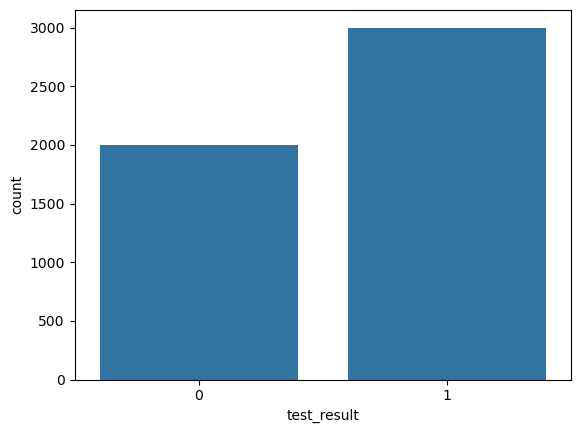

In [7]:
# idem via visualisatie:
sns.countplot(data=df,x='test_result')

<Axes: xlabel='test_result', ylabel='age'>

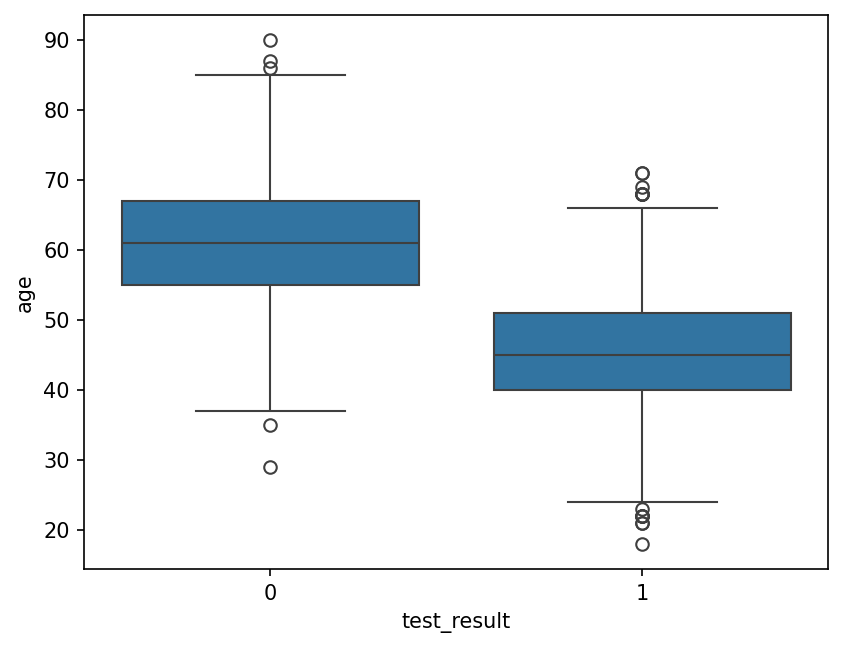

In [8]:
# Interessant: visualisatie van de features per categorie via boxplot
# -> Is er een verschil tussen leeftijd en testresult? JA! Mensen die niet slagen, zijn ouder...
plt.figure(dpi=150)
sns.boxplot(x='test_result',y='age',data=df)

<Axes: xlabel='test_result', ylabel='physical_score'>

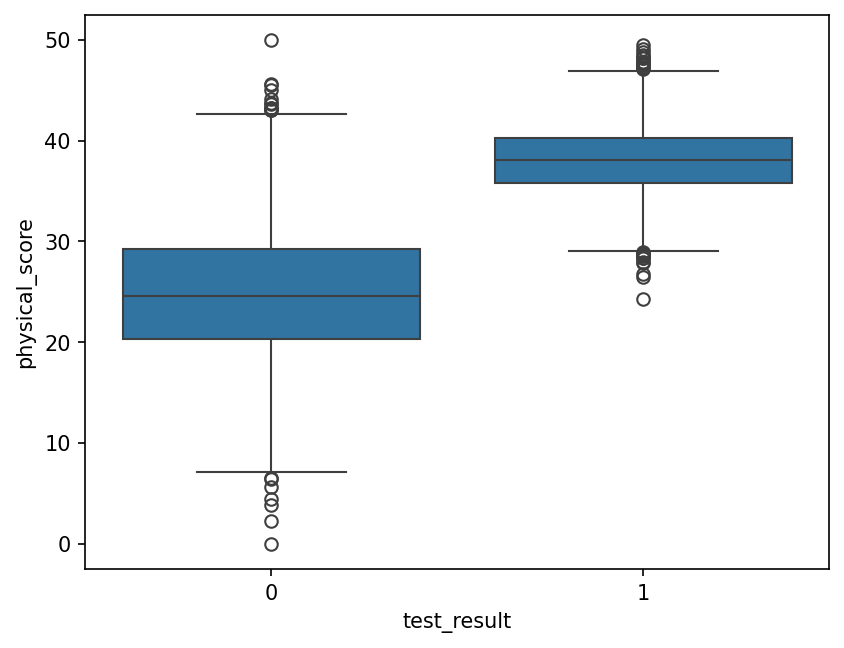

In [9]:
# Idem voor de relatie met score op de fysieke test - zelfs nog meer afgetekend resultaat! 
# Er is een grote spreiding in fysieke score voor mensen die niet slagen... maar als je een erg hoge fysieke 
# score hebt is de kans dat je slaagt voor de hoortest groot
plt.figure(dpi=150)
sns.boxplot(x='test_result',y='physical_score',data=df)

# Aangezien degenen die slagen voor de hoortest allemaal een goede fysieke test score hebben, zou dat kunnen 
# zijn omdat ze jong zijn?  Hoe kunnen we dit nagaan?

<Axes: xlabel='age', ylabel='physical_score'>

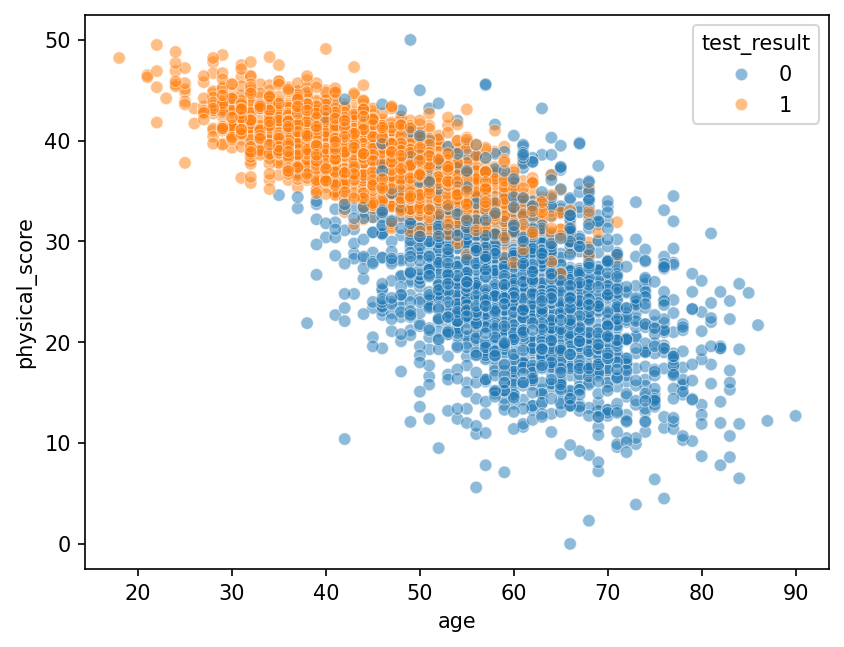

In [10]:
# Onderzoek relatie fysieke score en leeftijd
plt.figure(dpi=150)
sns.scatterplot(x='age',
                y='physical_score',
                data=df,
                hue='test_result', 
                alpha=0.5
               )

<Figure size 960x720 with 0 Axes>

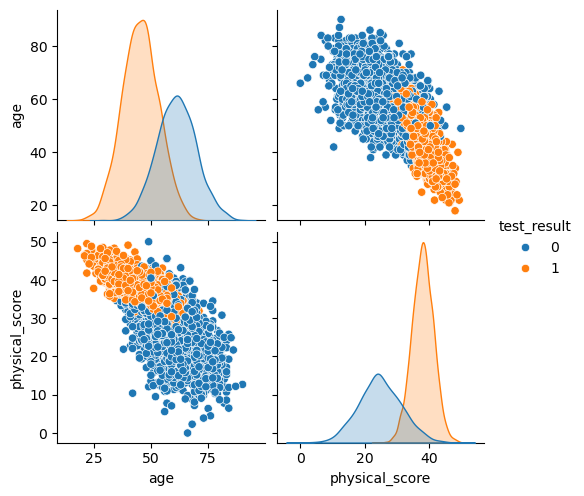

In [11]:
# Voor classificatie is het aangewezen om een pairplot of heatmap aan te maken; zo krijgen we de distributie en scatterplots van de klasses 
plt.figure(dpi=150)
sns.pairplot(df,hue='test_result')

<Axes: >

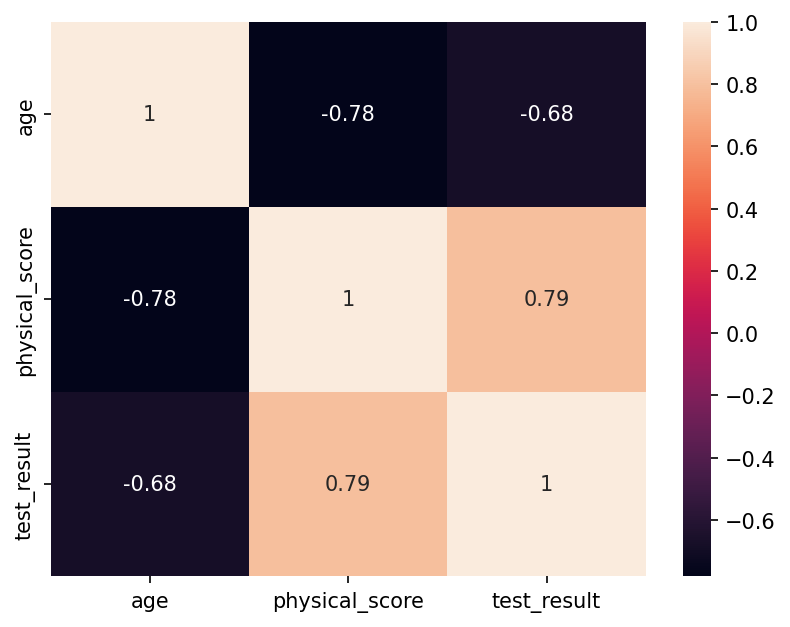

In [12]:
# nagaan van de correlatie tussen de features
plt.figure(dpi=150)
sns.heatmap(df.corr(),annot=True)

Dit toont de hoge correlatie tussen slagen voor de test en de physical_score feature; bij age negatieve correlatie omdat met toenemende leeftijd de kans afneemt om te slagen voor de test

Als je werkt met klasses zullen scatterplots niet goed werken als je as gebaseerd is op de klasse zoals test_result.  Dit kan al dan niet informatief zijn.  In onderstaand geval zien we ahw de distributie per klasse; dit lijkt meer op een boxplot zoals we hogerop hebben gezien.

<Axes: xlabel='physical_score', ylabel='test_result'>

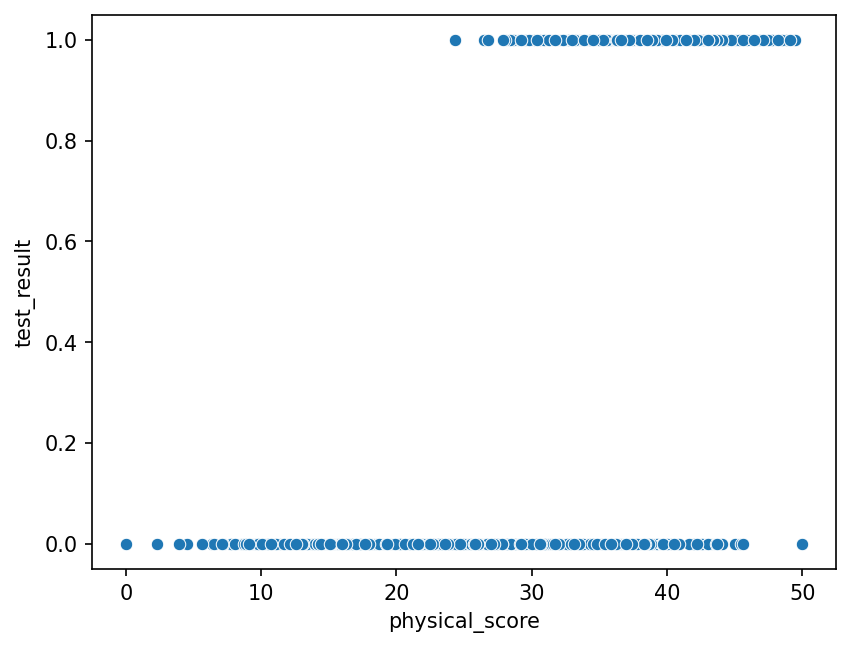

In [13]:
plt.figure(dpi=150)
sns.scatterplot(x='physical_score',y='test_result',data=df)

<Axes: xlabel='age', ylabel='test_result'>

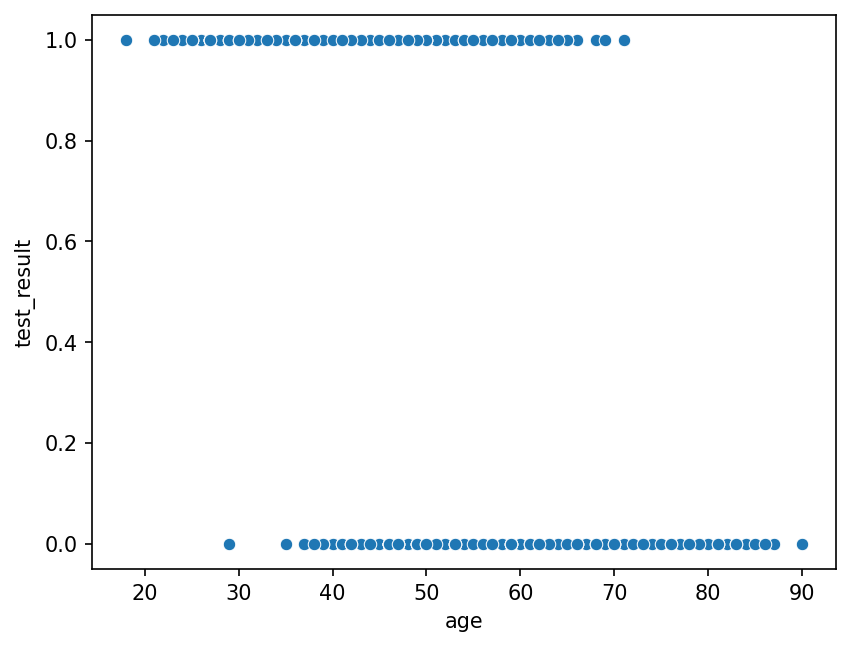

In [14]:
plt.figure(dpi=150)
sns.scatterplot(x='age',y='test_result',data=df)

Indien de dataset klein is en er weinig features zijn kunnen we deze in 3D weergeven!  

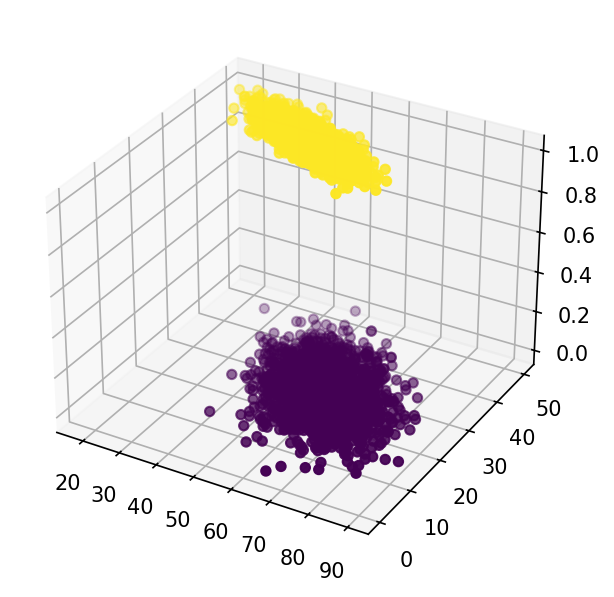

In [15]:
fig = plt.figure(dpi=150)
ax = fig.add_subplot(projection='3d')
ax.scatter(df['age'],df['physical_score'],df['test_result'],c=df['test_result'])

Er is duidelijk onderscheid waar te nemen tussen diegenen die slaagden voor de test, en degenen die niet slaagden.  Het model zou dus een goede voorspelling moeten kunnen doen!

### Train | Test Split en Scaling

In [16]:
X = df.drop('test_result',axis=1)
y = df['test_result']

Ook hier willen we de features scalen, vooral als we coëfficiënten met elkaar willen vergelijken.  Eerst splitten en dan scalen!

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [19]:
scaler = StandardScaler()

In [20]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Maken van het Logistic Regression Model

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
# help(LogisticRegression)

In [23]:
# help(LogisticRegressionCV)

In [24]:
log_model = LogisticRegression()

In [25]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

In [26]:
log_model.coef_

array([[-0.94953524,  3.45991194]])

Dingen om te onthouden:

* Deze coëfficiënten hebben betrekking op de kansen en kunnen niet direct worden geïnterpreteerd zoals in lineaire regressie.
* We hebben getraind op een geschaalde versie van de gegevens.
* Het is veel eenvoudiger om de relatie tussen de coëfficiënten te begrijpen en te interpreteren dan om de relatie van de coëfficiënten met de waarschijnlijkheid van de doel/label klasse te interpreteren.

Dit betekent:

* We kunnen verwachten dat de kansen om voor de test te slagen afnemen (de oorspronkelijke coëfficiënt was negatief) per eenheid toename van de leeftijd.
* We kunnen verwachten dat de kansen om voor de test te slagen toenemen (de oorspronkelijke coëfficiënt was positief) per eenheid toename van de lichamelijke score.
* Op basis van de verhoudingen ten opzichte van elkaar is de indicator lichamelijke_score een sterkere voorspeller dan leeftijd.

In [27]:
# voorspellingen - klasses
y_pred = log_model.predict(scaled_X_test)
y_pred

array([1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,

In [28]:
# voorspellingen - kansen
y_pred = log_model.predict_proba(scaled_X_test)
y_pred

array([[2.38434328e-02, 9.76156567e-01],
       [2.69240761e-02, 9.73075924e-01],
       [9.89194168e-01, 1.08058325e-02],
       [1.90768955e-03, 9.98092310e-01],
       [9.75012619e-01, 2.49873806e-02],
       [9.89652504e-01, 1.03474957e-02],
       [7.40226674e-02, 9.25977333e-01],
       [1.70943342e-02, 9.82905666e-01],
       [9.97066033e-01, 2.93396692e-03],
       [3.30521615e-02, 9.66947839e-01],
       [8.31035903e-02, 9.16896410e-01],
       [9.92865306e-03, 9.90071347e-01],
       [7.08965218e-03, 9.92910348e-01],
       [9.34236379e-01, 6.57636209e-02],
       [1.16594927e-04, 9.99883405e-01],
       [6.58904151e-02, 9.34109585e-01],
       [9.89126706e-01, 1.08732938e-02],
       [2.80051357e-03, 9.97199486e-01],
       [5.58920624e-04, 9.99441079e-01],
       [9.96523291e-01, 3.47670946e-03],
       [8.81757060e-01, 1.18242940e-01],
       [1.31030473e-01, 8.68969527e-01],
       [5.45646751e-01, 4.54353249e-01],
       [3.44064171e-02, 9.65593583e-01],
       [3.983864